In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd


In [2]:
dfs = []
dfs.append(pd.read_csv('sizing_data_woSuramin.csv'))
dfs.append(pd.read_csv('sizing_data_wSuramin.csv'))

In [3]:
#-----------------------------------------------------------------------
# Two-state binding model for    G3BP1 + RNA --- G3BP1*RNA complex
# Binding equilibrium described by G3BP1-RNA dissociation constant K_D
# Hold total concentration P_0 = [G3BP1] + [RNA] fixed
#-----------------------------------------------------------------------


#----------------------------------------
# Model to infer K_D, with P0 fixed to 1
#----------------------------------------
def sizing_fit(RNA0, k, R1, R2):
    P0 = 1.0
    RNA0 = np.asarray(RNA0, dtype=float)
    Delta = (k + RNA0 + P0)**2 - 4.0 * P0 * RNA0
    Delta = np.maximum(Delta, 0.0)
    C = 0.5 * (P0 + RNA0 + k - np.sqrt(Delta))
    C = np.clip(C, 0.0, P0)
    P = P0 - C
    # since P+C = P0, denominator is P0; keep form explicit
    return (R1 * P + R2 * C) / (P + C)

# --- Data ---
xFit = dfs[0]['RNA'].to_numpy(dtype=float)
yFit = dfs[0]['Average'].to_numpy(dtype=float)
sigma = dfs[0]['Std'].to_numpy(dtype=float)
sigma = np.where(np.isfinite(sigma) & (sigma > 0), sigma, np.nanmedian(sigma[sigma > 0]))

# --- Weighted fit ---
p0 = (100.0, 7.0, 50.0)  # (k, R1, R2) as you used
bounds = ([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf])

popt, pcov = curve_fit( sizing_fit, xFit, yFit, p0=p0, bounds=bounds,
    sigma=sigma, absolute_sigma=True, maxfev=200000 )

perr = np.sqrt(np.diag(pcov))
names = ["k", "R1", "R2"]

print("\n===== Fit Results =====\n")
for name, val, err in zip(names, popt, perr):
    print(f"{name:>2} = {val:.6g} ± {err:.2g}")

corr = pcov / np.outer(perr, perr)
print("\n===== Correlation matrix =====\n")
np.set_printoptions(precision=3, suppress=True)
print(corr)




===== Fit Results =====

 k = 123.151 ± 21
R1 = 7.43982 ± 0.2
R2 = 19.5409 ± 0.6

===== Correlation matrix =====

[[1.    0.515 0.706]
 [0.515 1.    0.189]
 [0.706 0.189 1.   ]]


In [4]:
#Bootstrap resampling of points
def bootstrap(n=2000, seed=1):
    rng = np.random.default_rng(seed)
    pars = []
    N = len(xFit)
    nfail = 0

    for _ in range(n):
        idx = rng.integers(0, N, N)
        xb, yb, sb = xFit[idx], yFit[idx], sigma[idx]

        try:
            p, _ = curve_fit(
                sizing_fit,
                xb, yb,
                p0=popt,
                bounds=bounds,
                sigma=sb,
                absolute_sigma=True,
                maxfev=200000
            )
            if np.all(np.isfinite(p)):
                pars.append(p)
            else:
                nfail += 1
        except Exception as e:
            nfail += 1
            if nfail <= 10:
                print("failure:", repr(e))

    print(f"successes = {len(pars)}, failures = {nfail}")

    if len(pars) == 0:
        return np.empty((0, 3))
    return np.vstack(pars)



pars = bootstrap(n=2000, seed=2)

if len(pars) > 50:
    m = pars.mean(axis=0)
    s = pars.std(axis=0, ddof=1)
    lo = np.percentile(pars, 2.5, axis=0)
    hi = np.percentile(pars, 97.5, axis=0)

    print("\n===== Bootstrap =====")
    for i, name in enumerate(names):
        print(f"{name:>2} = {m[i]:.6g} ± {s[i]:.2g}   (95% CI: {lo[i]:.6g} – {hi[i]:.6g})")
else:
    print("\n[bootstrap] Too many failures; increase maxfev, adjust p0, or relax bounds.")

    
    

successes = 2000, failures = 0

===== Bootstrap =====
 k = 126.664 ± 3.3e+02   (95% CI: 18.2373 – 252.652)
R1 = 7.42801 ± 0.49   (95% CI: 6.92522 – 8.97924)
R2 = 19.8911 ± 26   (95% CI: 12.4908 – 20.6955)


In [5]:
# Investigate median
for i, name in enumerate(["k","R1","R2"]):
    med = np.median(pars[:, i])
    lo, hi = np.percentile(pars[:, i], [2.5, 97.5])
    print(f"{name:>2} median = {med:.6g}   (95% CI: {lo:.6g} – {hi:.6g})")

 k median = 116.434   (95% CI: 18.2373 – 252.652)
R1 median = 7.3239   (95% CI: 6.92522 – 8.97924)
R2 median = 19.4569   (95% CI: 12.4908 – 20.6955)


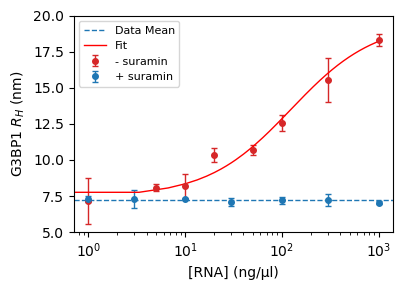

In [6]:
# -----
# Plot
# -----
plt.figure(figsize = (4,3))

# ---------------------------
# Generate smooth fit curve
# ---------------------------
x_smooth = np.linspace(np.min(xFit), np.max(xFit), 300)
y_smooth = sizing_fit(x_smooth, *popt)


# Without suramin modulation: raw data
plt.errorbar( dfs[0]['RNA'], dfs[0]['Average'], yerr=dfs[0]['Std'],
            fmt='o', markersize=4,
            color='tab:red', ecolor='tab:red',
            elinewidth=1, capsize=2.2, label='- suramin' )

# With suramin modulation: raw data
plt.errorbar( dfs[1]['RNA'], dfs[1]['Average'], yerr=dfs[1]['Std'],
            fmt='o', markersize=4,
            color='tab:blue', ecolor='tab:blue',
            elinewidth=1, capsize=2.2, label='+ suramin' )

# With suramin modulation: raw data mean
avg0 = np.mean(dfs[1]['Average'].values)
plt.axhline(avg0, c = 'tab:blue', lw=1.0, linestyle = 'dashed', label='Data Mean')

# Fitted curve
plt.plot(x_smooth, y_smooth, color='red', lw=1.0, label='Fit')

# Labels
plt.xlabel(r'[RNA] (ng/μl)')
plt.ylabel(r'G3BP1 $R_H$ (nm)')

# Range
plt.xscale('log')
plt.ylim(5, 20)

# Legend 
plt.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()